<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/EXP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 SMART AGRICULTURE LIVE MONITORING 
Fields Processed : 10/10
Monitoring Time  : 18 sec



,Field,Soil Temperature (°C),Soil Moisture (%),Humidity (%),Status
0,F01,34.12,72.77,48.41,NORMAL
1,F02,38.11,52.96,61.84,NORMAL
2,F03,23.57,79.39,36.62,NORMAL
3,F04,29.23,47.85,31.25,NORMAL
4,F05,18.86,66.99,33.97,NORMAL
5,F06,34.59,24.87,79.80,CRITICAL
6,F07,21.48,35.47,45.73,NORMAL
7,F08,33.26,72.67,40.85,NORMAL
8,F09,35.31,28.56,75.15,CRITICAL
9,F10,30.59,11.09,74.58,CRITICAL



Normal Fields : 7
Critical Fields : 3

⚠️ LOW SOIL MOISTURE ALERT ⚠️


,Field,Soil Temperature (°C),Soil Moisture (%),Humidity (%),Status
5,F06,34.59,24.87,79.80,CRITICAL
8,F09,35.31,28.56,75.15,CRITICAL
9,F10,30.59,11.09,74.58,CRITICAL


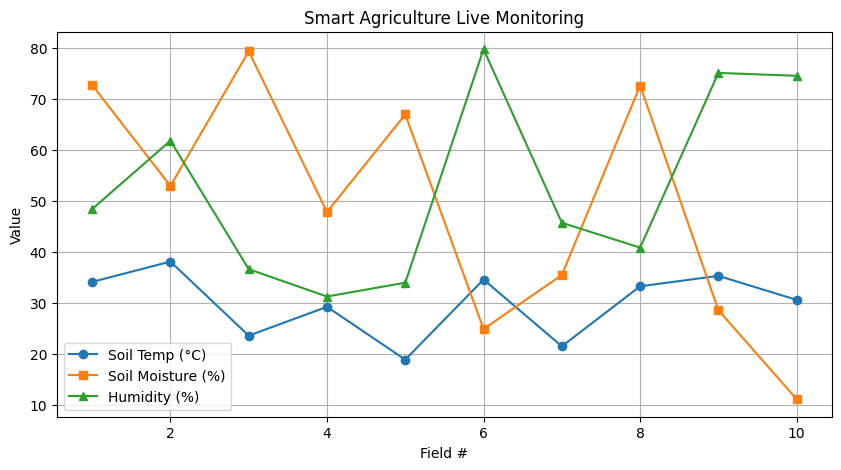


Monitoring Completed Successfully!


In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================================
# PART 1 - CONFIGURATION AND SETUP
# ==========================================================
TOTAL_FIELDS = 10       # number of fields to simulate
UPDATE_INTERVAL = 2     # seconds between updates
MOISTURE_CRITICAL_THRESHOLD = 30  # below this % moisture -> CRITICAL

# Storage lists (must exist before the loop appends to them)
field_ids = []
soil_temperatures = []
soil_moistures = []
humidities = []
status_list = []
time_axis = []

def generate_crop():
    """Simulate one field's sensor reading."""
    soil_temp = round(random.uniform(18, 40), 2)      # deg C
    soil_moisture = round(random.uniform(10, 80), 2)  # %
    humidity = round(random.uniform(30, 90), 2)        # %
    status = "CRITICAL" if soil_moisture < MOISTURE_CRITICAL_THRESHOLD else "NORMAL"
    return soil_temp, soil_moisture, humidity, status

def live_graph():
    """Plot the current readings so far."""
    fig = plt.figure(figsize=(10, 5))
    plt.plot(time_axis, soil_temperatures, marker='o', label="Soil Temp (°C)")
    plt.plot(time_axis, soil_moistures, marker='s', label="Soil Moisture (%)")
    plt.plot(time_axis, humidities, marker='^', label="Humidity (%)")
    plt.title("Smart Agriculture Live Monitoring")
    plt.xlabel("Field #")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.close(fig)  # prevents "too many open figures" warning over a long run

# ==========================================================
# PART 2 - LIVE MONITORING LOOP
# ==========================================================
for field in range(1, TOTAL_FIELDS + 1):
    # Generate field data
    soil_temp, soil_moisture, humidity, status = generate_crop()

    # Store values
    field_ids.append(f"F{field:02d}")
    soil_temperatures.append(soil_temp)
    soil_moistures.append(soil_moisture)
    humidities.append(humidity)
    status_list.append(status)
    time_axis.append(field)

    # Create DataFrame
    df = pd.DataFrame({
        "Field": field_ids,
        "Soil Temperature (°C)": soil_temperatures,
        "Soil Moisture (%)": soil_moistures,
        "Humidity (%)": humidities,
        "Status": status_list
    })

    # Clear previous output
    clear_output(wait=True)
    print("=" * 80)
    print(" SMART AGRICULTURE LIVE MONITORING ")
    print("=" * 80)
    print(f"Fields Processed : {field}/{TOTAL_FIELDS}")
    print(f"Monitoring Time  : {(field-1)*UPDATE_INTERVAL} sec")
    print()

    # Display live table
    display(df)

    # Critical fields
    critical = df[df["Status"] == "CRITICAL"]
    print("\nNormal Fields :", len(df) - len(critical))
    print("Critical Fields :", len(critical))
    if len(critical) > 0:
        print("\n⚠️ LOW SOIL MOISTURE ALERT ⚠️")
        display(critical)

    # Live graphs
    live_graph()

    # Wait before next update
    if field != TOTAL_FIELDS:
        time.sleep(UPDATE_INTERVAL)

print("\nMonitoring Completed Successfully!")